# This needs to be your file path!!

In [1]:
import sys, os
import pandas as pd
from pathlib import Path
import re

ELI_lamp_path = "/Users/cmcanespie/Documents/ELI_dosimetry_run/ELIUPXXX/ELIBL_Sep/"

# From here, nothing should change

In [2]:
ROOT_FOLDER = os.path.dirname(ELI_lamp_path) # point this to the folder containing LAMP
print(ROOT_FOLDER)
sys.path.append(ROOT_FOLDER)
from LAMP import Experiment
# ----------------------------------
import matplotlib.pyplot as plt 
import numpy as np
from scipy.signal import savgol_filter

def get_shot_time(filename):
    """
    Extract timestamp from filename such as:
    20260916T175151m490Z__eSpect_ChamberLo (25039545)__25039545.tiff
    """
    match = re.search(r"(\d{8})T(\d{6})m(\d{3})Z", filename)
    if match is None:
        return None

    date = match.group(1)
    time = match.group(2)
    milliseconds = match.group(3)
    timestamp = pd.to_datetime(date + time + milliseconds,format="%Y%m%d%H%M%S%f",utc=True)
    return timestamp

ex = Experiment(ROOT_FOLDER)

ESpec = ex.get_diagnostic('ESpec')

/Users/cmcanespie/Documents/ELI_dosimetry_run/ELIUPXXX/ELIBL_Sep
Initializing LAMP, version 0.2.1
Using (User) DAQ: ZEUSAug2026
Adding Diagnostic: ESpec [ESpec]


In [3]:
timeline = {'date': 20260910, 'run': 'scans/005'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec', timeline)
shot_dicts

[{'date': 20260910, 'run': 'scans/005', 'shotnum': 1},
 {'date': 20260910, 'run': 'scans/005', 'shotnum': 2}]

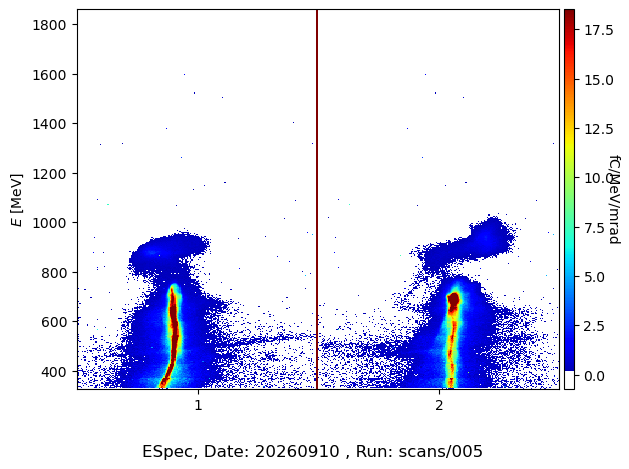

In [4]:
timeline = {'date': 20260910, 'run': 'scans/005'}

ESpec.montage(timeline)
plt.tight_layout()

# Get spectra em

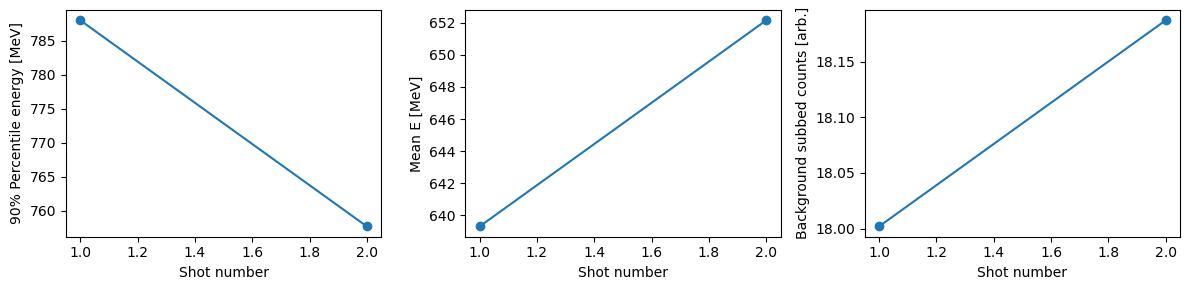

In [5]:
E_means, E_stds, E_percs, E_charges = ESpec.get_spectra_metrics(timeline, roi_MeV=[500,1600], roi_mrad=None, percentile=90, debug=False)

fig, ax = plt.subplots(1,3,figsize=(12,3))

ax[2].plot(np.arange(len(E_charges))+1, E_charges, '-o')
ax[2].set_xlabel('Shot number')
ax[2].set_ylabel('Background subbed counts [arb.]')

ax[1].plot(np.arange(len(E_means))+1, E_means, '-o')
ax[1].set_xlabel('Shot number')
ax[1].set_ylabel('Mean E [MeV]')

ax[0].plot(np.arange(len(E_percs))+1, E_percs, '-o')
ax[0].set_xlabel('Shot number')
ax[0].set_ylabel('90% Percentile energy [MeV]')

plt.tight_layout()

# Plot an individual shot

for checking things

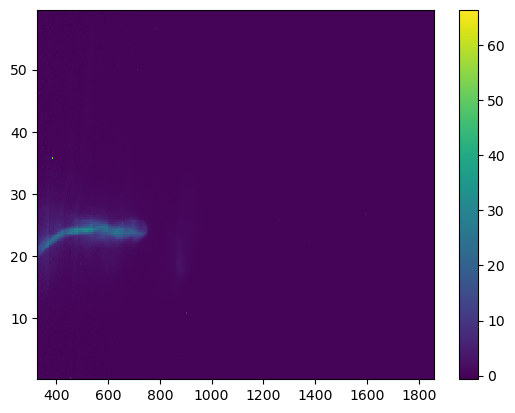

In [6]:
eg_shot = {'date': 20260910, 'run': 'scans/005', 'shotnum': 1}
img, x, y = ESpec.get_proc_shot(eg_shot, debug=False)

plt.pcolormesh(x, y, img)
plt.colorbar()

# Plot overplotted spectra

For when nothing is changed in a run

/var/folders/v8/x5tmn3653v7btc9h58b94mlh0000gn/T/ipykernel_89376/963877323.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  charge.append(abs(np.trapz(spec, x=MeV)))


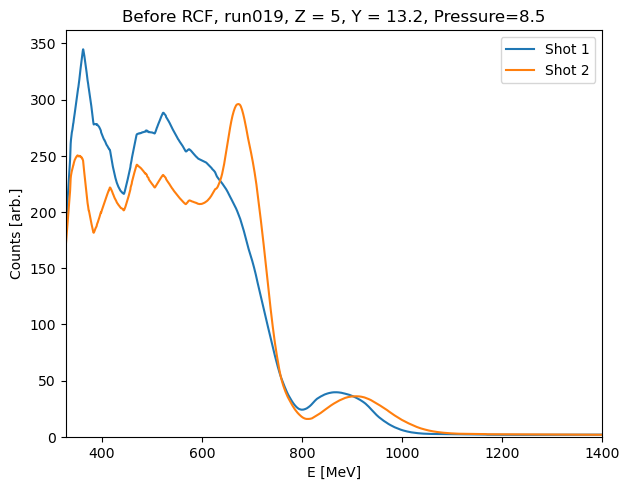

104922.87077344098 3372.8714017940583


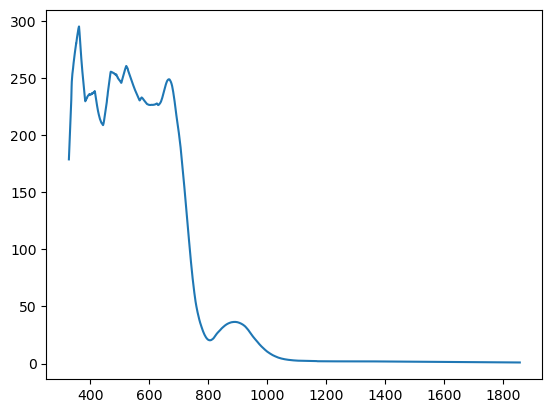

In [7]:
timeline = {'date': 20260910, 'run': 'scans/005'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec', timeline)

charge = []
ave_spec = []

for n,i in enumerate(shot_dicts):
    img, MeV, y = ESpec.get_proc_shot(i, debug=False)
    img[img<=0] = 0

    spec = abs(np.sum(img, axis=0))
    
    spec = savgol_filter(spec, window_length=61, polyorder=1) # Smooth out the spectra if it has bumps in it
    plt.plot(MeV, spec, label='Shot '+str(n+1))
    charge.append(abs(np.trapz(spec, x=MeV)))
    ave_spec.append(spec)

plt.legend()
plt.xlabel('E [MeV]')
plt.ylabel('Counts [arb.]')
plt.ylim(0, )
plt.xlim(np.min(MeV), 1400)
plt.tight_layout()
plt.title('Before RCF, run019, Z = 5, Y = 13.2, Pressure=8.5')
plt.show()

ave_spec_over_run = np.mean(ave_spec, axis=0)

plt.plot(MeV, ave_spec_over_run)

print(np.mean(charge), np.std(charge))

In [8]:
gain_value = 100
gain_dB = 0.1 * gain_value
gain_linear = 10**(gain_dB / 20)

ND = 0.5  # change to your ND filter
transmission = 10**(-ND)

int_counts = 3.66E7

charge_fC = (int_counts * (85.5 / 4096)/ gain_linear/ transmission)

# print("Charge =", charge_fC, "fC")
print("Charge =", charge_fC / 1000, "pC")

Charge = 763.9892578124999 pC


# Guiding check

In [9]:
gain_value = 240
gain_dB = 0.1 * gain_value
gain_linear = 10**(gain_dB / 20)

int_counts = 1.9e6

charge_fC = int_counts * (85.5 / 4096) / gain_linear

print("Charge =", charge_fC / 1000, "pC")

Charge = 2.50241749538104 pC


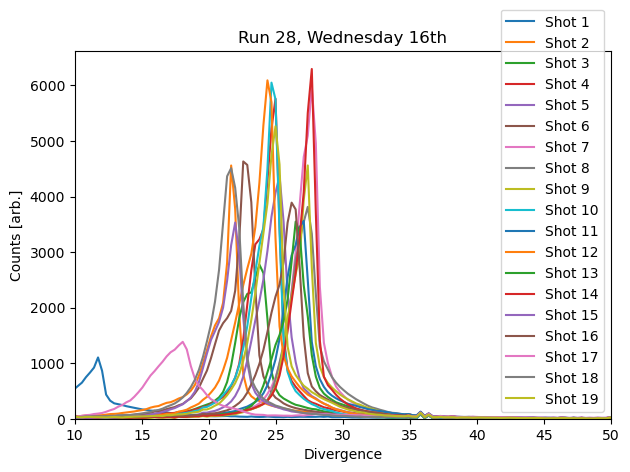

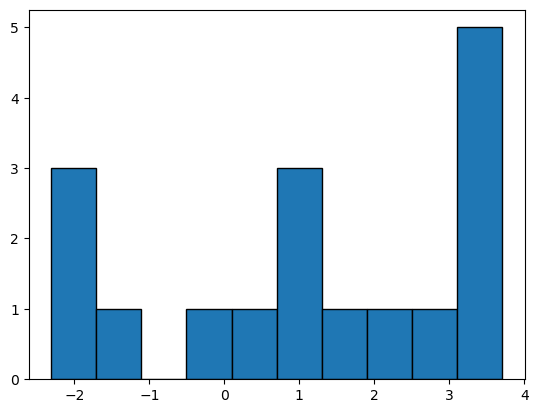

np.float64(2.0720127052894854)

In [16]:
timeline = {'date': 20260910, 'run': 'scans/004'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec', timeline)

vert_pointing = []

for n,i in enumerate(shot_dicts):
    spec, mrad = ESpec.get_div(i)
    # spec = savgol_filter(spec, window_length=51, polyorder=1) # Smooth out the spectra if it has bumps in it
    plt.plot(mrad, spec, label='Shot '+str(n+1))
    pos_max = mrad[np.argmax(spec)]
    vert_pointing.append(pos_max)

plt.legend()
plt.xlabel('Divergence')
plt.ylabel('Counts [arb.]')
plt.ylim(0, )
plt.xlim(10,50)
plt.title('Run 28, Wednesday 16th')
plt.tight_layout()
plt.show()

vert_pointing = np.array(vert_pointing)
vert_pointing = vert_pointing-np.mean(vert_pointing)

vert_pointing = vert_pointing[vert_pointing>-4]


plt.hist(vert_pointing, edgecolor='k')
plt.show()

np.std(vert_pointing)

In [21]:
FWHM_vals = []
for n,i in enumerate(shot_dicts):
    x, y = ESpec.get_div_FWHM(i)
    FWHM_vals.append(x)
    # print('FWHM = ', x)

np.mean(FWHM_vals), np.min(FWHM_vals), np.std(FWHM_vals)

(np.float64(3.5138827170692335),
 np.float64(3.30750719633906),
 np.float64(0.2772504173536219))

In [19]:
3.5/2*np.sqrt(np.log(2))

np.float64(1.456970569525971)

# Pressure scan - get the data

In [35]:
log_file = "/Users/cmcanespie/Documents/ELI_dosimetry_run/ELIUPXXX/Cameras/20260910/Bronk1@COM4.csv"
log = pd.read_csv(log_file, sep=";")
log["TimeUTC"] = pd.to_datetime(log["TimeUTC"], utc=True)

ELI_data_path = "/Users/cmcanespie/Documents/ELI_dosimetry_run/ELIUPXXX/Cameras/"
folder = Path(str(ELI_data_path)+'/20260910/scans/003/espec/')

files = sorted(folder.glob("*.tif*"))

timeline = {'date': 20260910, 'run': 'scans/002'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec', timeline)


for n,i in enumerate(shot_dicts[5:]):
    spec, MeV = ESpec.get_spectrum(i)
    spec = savgol_filter(spec, window_length=61, polyorder=1) # Smooth out the spectra if it has bumps in it
    plt.plot(MeV, spec, label='Shot '+str(n+1))

plt.legend()
plt.xlabel('E [MeV]')
plt.ylabel('Counts [arb.]')
plt.ylim(0, )
plt.xlim(np.min(MeV), 1400)
plt.tight_layout()
plt.title('Run 28, Wednesday 16th')


Text(0.5, 1.0, 'Run 28, Wednesday 16th')

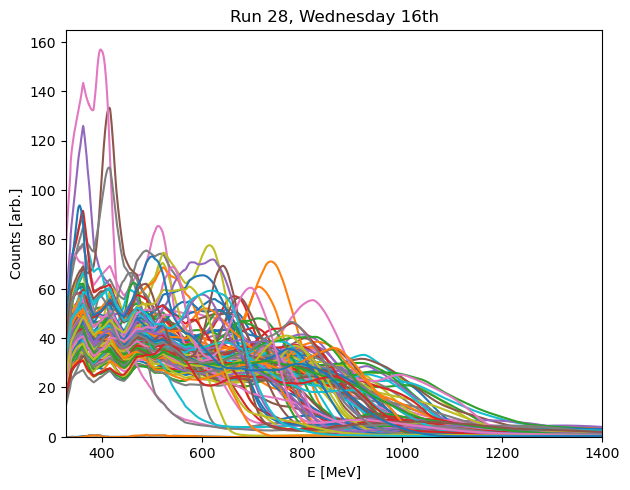

In [77]:
log_file = "/Users/cmcanespie/Documents/ELI_dosimetry_run/ELIUPXXX/Cameras/20260910/Bronk1@COM4.csv"
log = pd.read_csv(log_file, sep=";")
log["TimeUTC"] = pd.to_datetime(log["TimeUTC"], utc=True)

ELI_data_path = "/Users/cmcanespie/Documents/ELI_dosimetry_run/ELIUPXXX/Cameras/"
folder = Path(str(ELI_data_path) + '/20260910/scans/003/espec/')

files = sorted(folder.glob("*.tif*"), key=lambda x: get_shot_time(x.name))

timeline = {'date': 20260910, 'run': 'scans/003'}
shot_dicts = ex.DAQ.get_shot_dicts('ESpec', timeline)

shots_nums = []
pressure_read = []
pressure_set = []

for n, i in enumerate(shot_dicts[5:]):
    shotnum = i["shotnum"]
    file = files[shotnum - 1]

    shots_nums.append(shotnum)

    shot_time = get_shot_time(file.name)

    time_difference = abs(log["TimeUTC"] - shot_time)
    closest_index = time_difference.idxmin()

    pressure = log.loc[closest_index, "PressureSetpoint"]
    pressure_set.append(pressure)

    pressure = log.loc[closest_index, "PressureRead"]
    pressure_read.append(pressure)

    spec, MeV = ESpec.get_spectrum(i)
    spec = savgol_filter(spec, window_length=61, polyorder=1) # Smooth out the spectra if it has bumps in it
    plt.plot(MeV, spec, label='Shot ' + str(shotnum) + ', P = ' + str(round(pressure, 1)))

plt.xlabel('E [MeV]')
plt.ylabel('Counts [arb.]')
plt.ylim(0, )
plt.xlim(np.min(MeV), 1400)
plt.tight_layout()
plt.title('Run 28, Wednesday 16th')

5800.0 [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
5700.0 [16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
5600.0 [28, 29, 30, 31, 32, 33, 34, 35, 36]
5500.0 [37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
5400.0 [48, 49, 50, 51, 52, 53, 54, 55]
6000.0 [56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106]
6500.0 [72, 73, 74]
6200.0 [75, 76, 77, 78, 79, 80, 81]


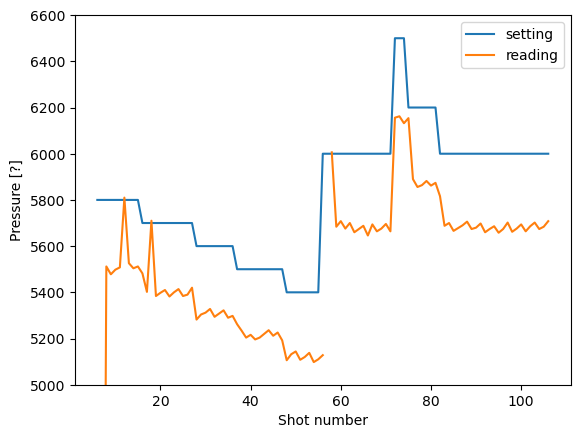

In [78]:
plt.plot(shots_nums, pressure_set, label='setting')
plt.plot(shots_nums, pressure_read, label='reading')
plt.ylim(5000,6600)
plt.legend()
plt.ylabel('Pressure [?]')
plt.xlabel('Shot number')

pressure_rounded = np.round(pressure_set, -2)

pressure_groups = {}

for shot, pressure in zip(shots_nums, pressure_rounded):
    pressure_groups.setdefault(pressure, []).append(shot)

for pressure, shots in pressure_groups.items():
    print(pressure, shots)

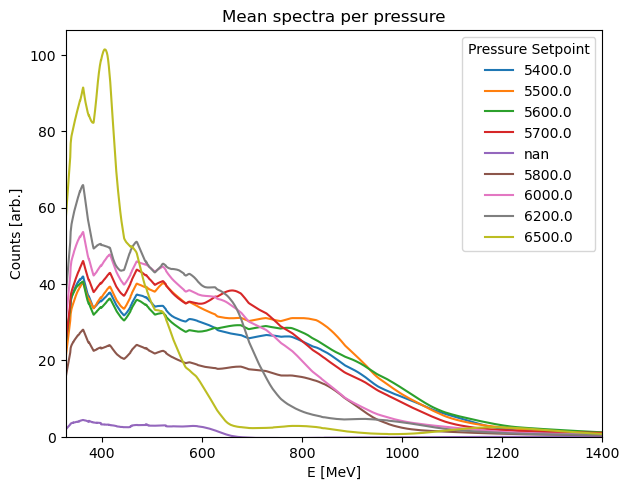

In [79]:
spectra_by_pressure = {}

for n, i in enumerate(shot_dicts):
    shotnum = i["shotnum"]
    file = files[shotnum - 1]

    shot_time = get_shot_time(file.name)

    time_difference = abs(log["TimeUTC"] - shot_time)
    closest_index = time_difference.idxmin()

    pressure = log.loc[closest_index, "PressureSetpoint"]

    spec, MeV = ESpec.get_spectrum(i)
    spec = savgol_filter(spec, window_length=61, polyorder=1)

    # Store spectrum according to pressure setpoint
    if pressure not in spectra_by_pressure:
        spectra_by_pressure[pressure] = []

    spectra_by_pressure[pressure].append(spec)


# Plot average spectrum for each pressure setpoint
for pressure, spectra in sorted(spectra_by_pressure.items()):

    spectra = np.array(spectra)

    mean_spec = np.mean(spectra, axis=0)

    plt.plot(
        MeV,
        mean_spec,
        label=str(pressure)
    )

plt.legend(title='Pressure Setpoint')
plt.xlabel('E [MeV]')
plt.ylabel('Counts [arb.]')
plt.ylim(0, )
plt.xlim(np.min(MeV), 1400)
plt.tight_layout()
plt.title('Mean spectra per pressure')
plt.show()

/var/folders/v8/x5tmn3653v7btc9h58b94mlh0000gn/T/ipykernel_20003/4036873461.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(mean_spec, MeV)


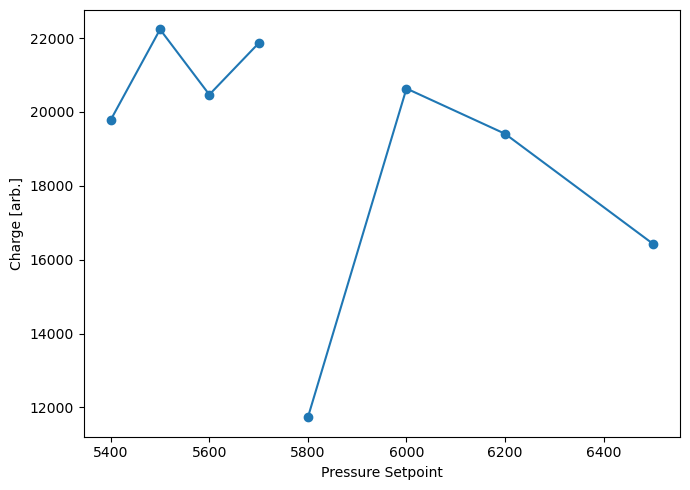

In [81]:
integrated_spectra = []
pressures = []

for pressure, spectra in sorted(spectra_by_pressure.items()):

    spectra = np.array(spectra)

    # Average spectrum at this pressure
    mean_spec = np.mean(spectra, axis=0)

    # Integrate average spectrum over energy
    integral = np.trapz(mean_spec, MeV)

    pressures.append(pressure)
    integrated_spectra.append(integral)


plt.figure(figsize=(7, 5))

plt.plot(pressures,integrated_spectra,'o-')

plt.xlabel('Pressure Setpoint')
plt.ylabel('Charge [arb.]')
plt.tight_layout()
plt.show()